In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

C:\Users\Atharva\AppData\Local\Temp\ipykernel_2820\2804636221.py:8: RuntimeWarning: invalid value encountered in log
  return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


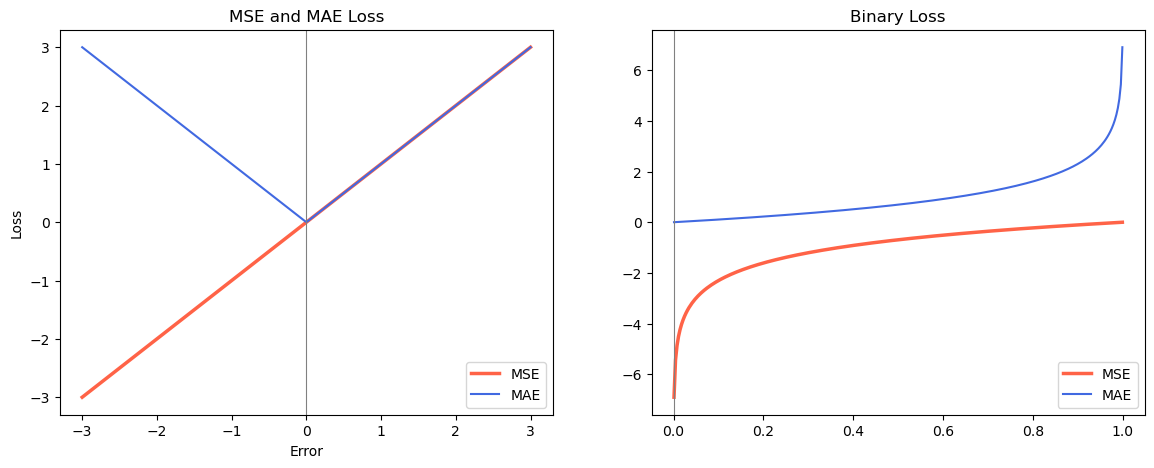

In [9]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def mae_loss(y_true, y_pred):
    return np.mean(np.abs(y_true-y_pred))

def binary_loss(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

y_true = np.array([1.0])
errors = np.linspace(-3, 3, 300)
y_pred = y_true+errors

mse = mse_loss(y_true, y_pred)
mae = mae_loss(y_true, y_pred)
binary = binary_loss(y_true, y_pred)

mse_vals = [(y_pre - y_true[0]**2) for y_pre in y_pred]
mae_vals = [np.abs(y_pre - y_true) for y_pre in y_pred]

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].plot(errors, mse_vals, color = 'tomato', label = 'MSE', lw = 2.5)
axes[0].plot(errors, mae_vals, color = 'royalblue', label = 'MAE')
axes[0].axvline(0, color = 'gray', lw = 0.8)
axes[0].legend()
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Loss')
axes[0].set_title('MSE and MAE Loss')
axes[0].annotate('MSE errors MORE', xy = (2, 4), fontsize = 10, color = 'tomato')
axes[0].annotate('MAE errors LESS', xy = (-2, 4), fontsize = 10, color = 'royalblue')

probs = np.linspace(0.001, 0.999, 300)
bce_y1 = np.log(probs)
bce_y2 = -np.log(1-probs)

axes[1].plot(probs, bce_y1, color = 'tomato', label = 'MSE', lw = 2.5)
axes[1].plot(probs, bce_y2, color = 'royalblue', label = 'MAE')
axes[1].axvline(0, color = 'gray', lw = 0.8)
axes[1].legend()
axes[1].set_title('Binary Loss')
plt.show()

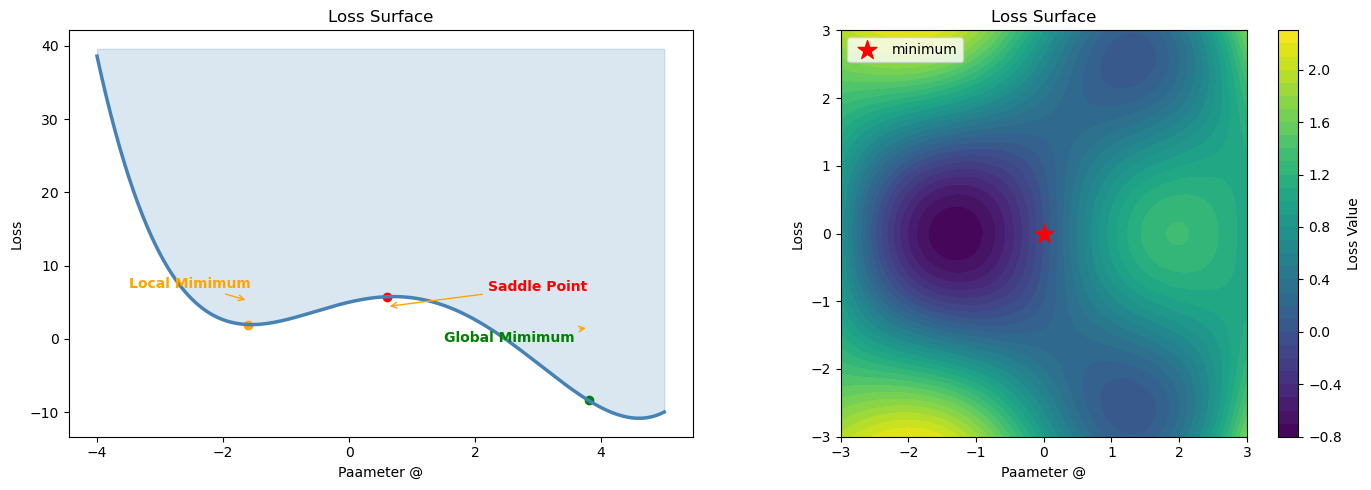

In [13]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

x = np.linspace(-4, 5, 500)
y = 0.1*x**4 - 0.5*x**3 - x**2 +2*x + 5

axes[0].plot(x, y, 'steelblue', lw = 2.5)
axes[0].fill_between(x, y, y.max() + 1, color = 'steelblue', alpha = 0.2)
axes[0].annotate('Local Mimimum', xy = (-1.6, 5.2), xytext = (-3.5, 7), fontsize = 10, color = 'orange', fontweight = 'bold', arrowprops = dict(arrowstyle = '->', color = 'orange'))
axes[0].annotate('Global Mimimum', xy = (3.8, 1.5), xytext = (1.5, -0.5), fontsize = 10, color = 'green', fontweight = 'bold', arrowprops = dict(arrowstyle = '->', color = 'orange'))
axes[0].annotate('Saddle Point', xy = (0.6 , 4.4), xytext = (2.2, 6.5), fontsize = 10, color = 'red', fontweight = 'bold', arrowprops = dict(arrowstyle = '->', color = 'orange'))
axes[0].scatter([-1.6], [y[np.argmin(np.abs(x + 1.6))]], color = 'orange')
axes[0].scatter([3.8], [y[np.argmin(np.abs(x - 3.8))]], color = 'green')
axes[0].scatter([0.6], [y[np.argmin(np.abs(x - 0.6))]], color = 'red')
axes[0].set_xlabel('Paameter @')
axes[0].set_title('Loss Surface')
axes[0].set_ylabel('Loss')

x2 = np.linspace(-3, 3, 200)
y2 = np.linspace(-3, 3, 200)

X, Y = np.meshgrid(x2, y2)
Z = np.sin(X) * np.cos(Y) + 0.1*(X**2 + Y**2)
contour = axes[1].contourf(X, Y, Z, levels = 30, cmap = 'viridis')
plt.colorbar(contour, ax = axes[1], label = 'Loss Value')
axes[1].set_xlabel('Paameter @')
axes[1].set_title('Loss Surface')
axes[1].set_ylabel('Loss')
axes[1].set_aspect('equal')

axes[1].scatter([0], [0], color = 'red', s = 200, marker = '*', zorder = 5, label = 'minimum')
axes[1].legend(loc = 'upper left')
plt.tight_layout()
plt.show()

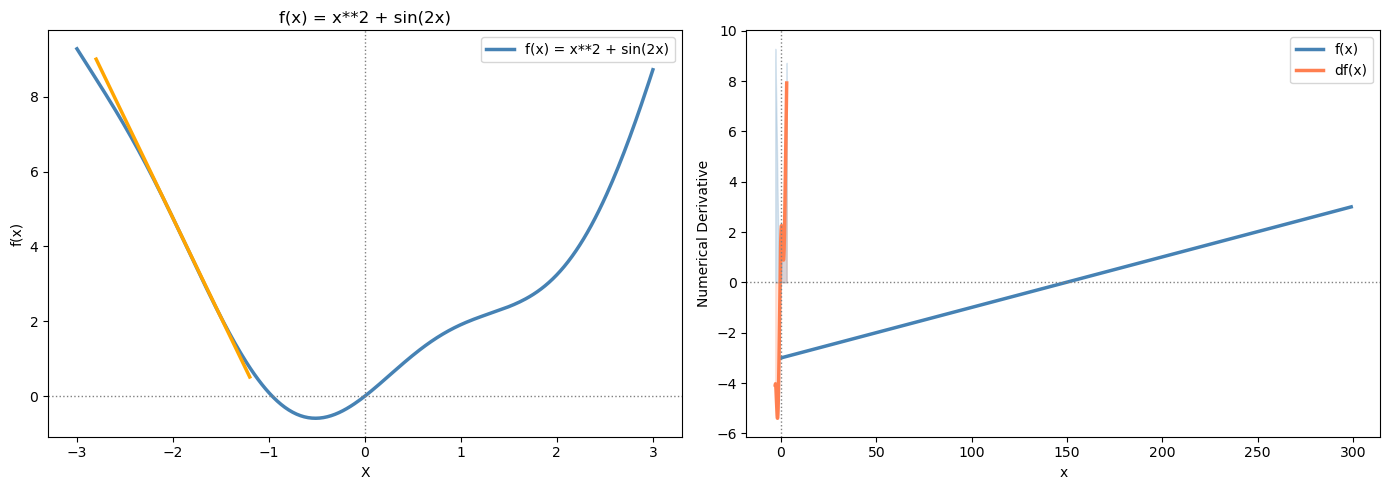

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [14]:
def numerical_derivative(f, x, h = 1e-6):
    return (f(x + h) - f(x - h))/(2*h)

f = lambda x: x**2 + np.sin(2*x)
df = lambda x: 2*x + 2*np.cos(2*x)

x_vals = np.linspace(-3, 3, 300)
y_vals = f(x_vals)
df_vals = df(x_vals)

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

axes[0].plot(x_vals, y_vals, color = 'steelblue', lw = 2.5, label = 'f(x) = x**2 + sin(2x)')
colors = ['orange', 'green', 'red']
points = [-2.0, 0.5, 2.0]

for pt, col in zip(points, colors):
    slope = df(pt)
    x_line = np.linspace(pt - 0.8, pt + 0.8, 50)
    y_line = f(pt) + slope*(x_line - pt)
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title('f(x) = x**2 + sin(2x)')
    axes[0].legend()
    axes[0].axhline(0, color = 'gray', lw = 1, linestyle = ':')
    axes[0].axvline(0, color = 'gray', lw = 1, linestyle = ':')
    axes[0].plot(x_line, y_line, color = col, lw = 2.5, label = f'Slope = {slope:.2f}')

    axes[1].plot(x_vals, color = 'steelblue', lw = 2.5, label = 'f(x)')
    axes[1].plot(x_vals, [df(x) for x in x_vals], 'coral', lw = 2.5, label = "df(x)")
    axes[1].axhline(0, color = 'gray', lw = 1, linestyle = ':')
    axes[1].axvline(0, color = 'gray', lw = 1, linestyle = ':')

    axes[1].fill_between(x_vals, [df(x) for x in x_vals], color = 'coral', alpha = 0.2)
    axes[1].fill_between(x_vals, [f(x) for x in x_vals], color = 'steelblue', alpha = 0.2)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel("Numerical Derivative")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def gradient_descent(f, df, x0, alpha = 0.1, max_iter = 1000, tol = 1e-6, verbose = True):
    x = x0
    x_history = [x]
    loss_history = [f(x)]
    for i in range(max_iter):
        grad = df(x)
        x_new = x - alpha*grad

        x_history.append(x_new)
        loss_history.append(x_new)
        loss_history.append(f(x_new))

        if abs(x_new - x) < tol:
            if verbose:
                print(f"Converged at Iteration")
            break

        x = x_new
    else:
        if verbose:
            print(f"Reach Max Iteration")
    return x_new, np.array(x_history), np.array(loss_history)